In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Load Heart Disease Dataset
- The dataset is loaded from a CSV file or UCI repository.
- Target variable: 0 (no heart disease) or 1 (heart disease).

In [2]:
# Load dataset (adjust path if needed)
# Alternatively, use: from sklearn.datasets import fetch_openml; data = fetch_openml(name='heart-disease')
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns)

# Handle missing values (marked as '?')
df = df.replace('?', np.nan)
df = df.dropna()

# Convert target to binary: >0 indicates heart disease
df['target'] = (df['target'] > 0).astype(int)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    object 
 12  thal      297 non-null    object 
 13  target    297 non-null    int32  
dtypes: float64(11), int32(1), object(2)
memory usage: 33.6+ KB


In [4]:
# Prepare features and target
X = df.drop('target', axis=1)
y = df['target']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=1)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (237, 13)
X_test shape: (60, 13)
y_train shape: (237,)
y_test shape: (60,)


## Logistic Regression without Regularization

In [5]:
# Train Logistic Regression (C=1e9 approximates no regularization)
lr = LogisticRegression(C=1e9, max_iter=1000)
lr.fit(X_train, y_train)

# Predict
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# Evaluate
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Logistic Regression without Regularization:")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

Logistic Regression without Regularization:
Train Accuracy: 0.8608
Test Accuracy: 0.8000

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        30
           1       0.78      0.83      0.81        30

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



## Logistic Regression with Polynomial Features (Inducing Overfitting)

In [6]:
# Create polynomial features
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X_scaled)

# Split polynomial data
X_poly_train, X_poly_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=1)

# Train Logistic Regression on polynomial features
lr_poly = LogisticRegression(C=1e9, max_iter=1000)
lr_poly.fit(X_poly_train, y_train)

# Predict
y_poly_train_pred = lr_poly.predict(X_poly_train)
y_poly_test_pred = lr_poly.predict(X_poly_test)

# Evaluate
poly_train_accuracy = accuracy_score(y_train, y_poly_train_pred)
poly_test_accuracy = accuracy_score(y_test, y_poly_test_pred)

print("\nLogistic Regression with Polynomial Features (Degree=3):")
print(f"Train Accuracy: {poly_train_accuracy:.4f}")
print(f"Test Accuracy: {poly_test_accuracy:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_poly_test_pred))


Logistic Regression with Polynomial Features (Degree=3):
Train Accuracy: 1.0000
Test Accuracy: 0.7833

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.77      0.80      0.79        30
           1       0.79      0.77      0.78        30

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



## Logistic Regression with Regularization

In [7]:
# Train Logistic Regression with L2 regularization
lr_reg = LogisticRegression(C=1.0, max_iter=1000)
lr_reg.fit(X_poly_train, y_train)

# Predict
y_reg_train_pred = lr_reg.predict(X_poly_train)
y_reg_test_pred = lr_reg.predict(X_poly_test)

# Evaluate
reg_train_accuracy = accuracy_score(y_train, y_reg_train_pred)
reg_test_accuracy = accuracy_score(y_test, y_reg_test_pred)

print("\nLogistic Regression with Regularization (C=1.0):")
print(f"Train Accuracy: {reg_train_accuracy:.4f}")
print(f"Test Accuracy: {reg_test_accuracy:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_reg_test_pred))


Logistic Regression with Regularization (C=1.0):
Train Accuracy: 1.0000
Test Accuracy: 0.7667

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        30
           1       0.77      0.77      0.77        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



## Visualization of Predictions

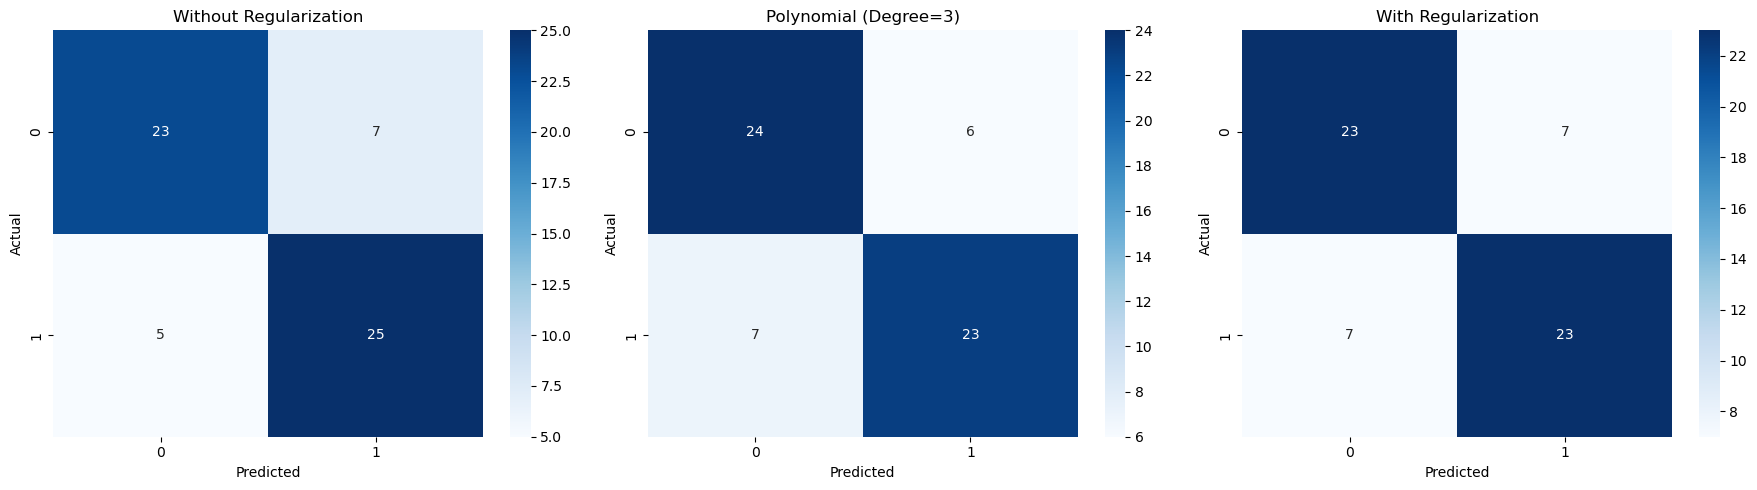

In [8]:
# Plot confusion matrices for comparison
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [('Without Regularization', y_test_pred), ('Polynomial (Degree=3)', y_poly_test_pred), ('With Regularization', y_reg_test_pred)]

for ax, (title, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('heart_disease_confusion_matrices.png')
plt.show()